In [12]:
import gensim.downloader as api
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Dropout
from tensorflow.keras.datasets import reuters
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Load Word2Vec model
print("Loading Word2Vec embeddings...")
word_vectors = api.load("word2vec-google-news-300")
print("Word2Vec loaded.")

# Load reuters dataset
vocab_size = 10000 # Limit vocabulary size to 10,000 most frequent words
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size)

Loading Word2Vec embeddings...
Word2Vec loaded.


In [13]:
# TODO: Preprocess dataset
max_len = 256  # puedes ajustar según la longitud promedio de los textos
input_length = 256
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [18]:
# TODO: Crear matriz de embeddings
word_index = reuters.get_word_index()

# Imprimir las primeras 10 palabras y sus índices en el diccionario word_index
for i, (word, index) in enumerate(word_index.items()):
    if i < 10:
        print(word, index)
    else:
        break

# Crear una matriz de embeddings con la misma longitud que el vocabulario
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for i, (word, index) in enumerate(word_index.items()):
    if i >= vocab_size:
        continue
    
    # Convertir la palabra a minúsculas (para evitar problemas con mayúsculas)
    word = word.lower()

    try:
        # Intentar obtener el vector de embedding
        embedding_vector = word_vectors[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        # Si la palabra no está en el vocabulario, asigna un vector aleatorio
        embedding_matrix[i] = np.random.normal(0, 1, 300)






mdbl 10996
fawc 16260
degussa 12089
woods 8803
hanging 13796
localized 20672
sation 20673
chanthaburi 20675
refunding 10997
hermann 8804


In [ ]:
# Function to build models
def build_model(use_pretrained, num_classes, output_dim,
                embedding_matrix, input_lenght=256): #el input_length es el tamaño de la secuencia de entrada y podrías no ponerlo y keras inferirlo por su cuenta
    """
    Builds and compiles a convolutional neural network model.

    Parameters:
    use_pretrained (bool): If True, use the pretrained embedding matrix; otherwise, 
        initialize embeddings randomly.
    output_dim (int): Dimension of the embedding vectors.
    num_classes (int): Number of output classes.
    embedding_matrix (np.array): Pretrained embedding matrix.

    Returns:
    tf.keras.Model: Compiled Keras model.
    """
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=output_dim, 
                  weights=[embedding_matrix] if use_pretrained else None,
                  trainable=True, input_length=256),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(5),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_pretrained = build_model(use_pretrained=True, num_classes=46, 
                                output_dim=embedding_dim, embedding_matrix=embedding_matrix)
model_random = build_model(use_pretrained=False, num_classes=46, 
                           output_dim=embedding_dim, embedding_matrix=None)


In [20]:
# TODO: Entrenar y evaluar modelos

# Entrenar el modelo con embeddings preentrenados
history_pretrained = model_pretrained.fit(x_train, y_train, epochs=10, 
                                          batch_size=64, validation_data=(x_test, y_test))

# Entrenar el modelo con embeddings aleatorios
history_random = model_random.fit(x_train, y_train, epochs=10, 
                                  batch_size=64, validation_data=(x_test, y_test))



Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.4114 - loss: 2.5104 - val_accuracy: 0.5516 - val_loss: 1.7848
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.5694 - loss: 1.7452 - val_accuracy: 0.6256 - val_loss: 1.5784
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.6502 - loss: 1.4274 - val_accuracy: 0.6643 - val_loss: 1.4403
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.7036 - loss: 1.1802 - val_accuracy: 0.6834 - val_loss: 1.3879
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.7576 - loss: 0.9872 - val_accuracy: 0.6963 - val_loss: 1.2988
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.8019 - loss: 0.7846 - val_accuracy: 0.7124 - val_loss: 1.2985
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8285 - loss: 0.6720 - val_accuracy: 0.7039 - val_loss: 1.3498
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.8488 - loss: 0

In [ ]:
# Evaluación en el conjunto de test
loss_pretrained, accuracy_pretrained = model_pretrained.evaluate(x_test, y_test) #accuracy de validación = 0.7181
loss_random, accuracy_random = model_random.evaluate(x_test, y_test) #accuracy de validación = 0.7815

print(f"Accuracy (pretrained): {accuracy_pretrained}")  #de validación
print(f"Accuracy (random): {accuracy_random}") #de validación


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7181 - loss: 1.4646
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7815 - loss: 1.2805
Accuracy (pretrained): 0.709260880947113
Accuracy (random): 0.7622439861297607


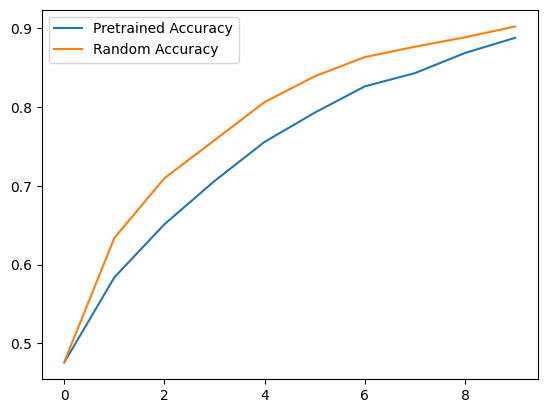

In [ ]:
plt.plot(history_pretrained.history['accuracy'], label='Pretrained Accuracy') #ploteamos los accuracy de entrenamiento de ambos modelos para verlos mejor
plt.plot(history_random.history['accuracy'], label='Random Accuracy')
plt.legend()
plt.show()
